**Customer Churn Prediction**

Extracting ZIP Dataset

In [1]:
import zipfile
import os

zip_file = "/content/customer_churn_dataset.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/churn_data')

print("Dataset Extracted Successfully!")

print("\nFiles Found:")
print(os.listdir('/content/churn_data'))

Dataset Extracted Successfully!

Files Found:
['Churn_Modelling.csv']


Importing Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

Automatically Finding CSV File

In [3]:
import glob

csv_files = glob.glob('/content/churn_data/**/*.csv',
                      recursive=True)

print("CSV Files Found:")
print(csv_files)

csv_path = csv_files[0]

print("\nSelected Dataset:")
print(csv_path)

CSV Files Found:
['/content/churn_data/Churn_Modelling.csv']

Selected Dataset:
/content/churn_data/Churn_Modelling.csv


Loading Dataset

In [4]:
df = pd.read_csv(csv_path)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Dataset Information

In [5]:
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore   

Data Preprocessing

In [6]:
columns_to_drop = [
    'RowNumber',
    'CustomerId',
    'Surname'
]

existing_columns = [
    col for col in columns_to_drop
    if col in df.columns
]

df.drop(existing_columns,
        axis=1,
        inplace=True)

# Encode object columns

label_encoder = LabelEncoder()

for column in df.columns:

    if df[column].dtype == 'object':

        df[column] = label_encoder.fit_transform(
            df[column]
        )

print("Preprocessing Completed")

Preprocessing Completed


Features and Target

In [7]:
target_column = 'Exited'

X = df.drop(target_column, axis=1)

y = df[target_column]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 10)
Target Shape: (10000,)


Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (8000, 10)
Testing Shape: (2000, 10)


Model Training

In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


Prediction

In [10]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0]


Accuracy Metric

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 86.45 %


Classification Report

In [12]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



Confusion Matrix

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1546   61]
 [ 210  183]]


Confusion Matrix Visualization

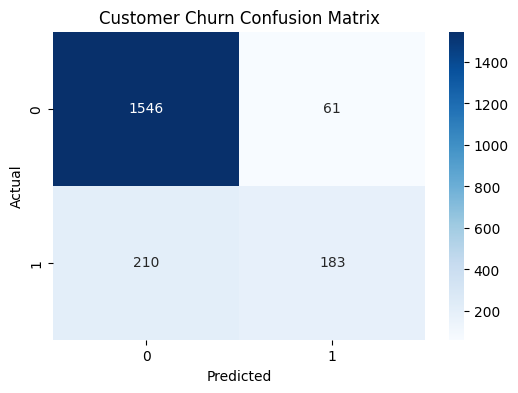

In [14]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Customer Churn Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Feature Importance

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

           Feature  Importance
3              Age    0.240453
9  EstimatedSalary    0.148004
0      CreditScore    0.142369
5          Balance    0.138670
6    NumOfProducts    0.132061
4           Tenure    0.080932
8   IsActiveMember    0.042807
1        Geography    0.037402
2           Gender    0.019032
7        HasCrCard    0.018269
